In [11]:
import numpy as np 
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt

In [4]:
url = "http://www.stat.cmu.edu/~larry/=stat401/bea-2006.csv"

resp = requests.get(url, verify=False)
resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text))
df.to_csv("bea-2006.csv", index=False)

print(df.head())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.stat.cmu.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


                           MSA  pcgmp       pop  finance  prof.tech      ict  \
0                  Abilene, TX  24490  158700.0  0.09750        NaN  0.01621   
1                    Akron, OH  32890  699300.0  0.12940    0.05440      NaN   
2                   Albany, GA  24270  163000.0  0.08217        NaN  0.00708   
3  Albany-Schenectady-Troy, NY  36840  850300.0  0.15780    0.09399  0.04511   
4              Albuquerque, NM  37660  816000.0  0.15990    0.09978  0.20500   

   management  
0         NaN  
1    0.054310  
2         NaN  
3         NaN  
4    0.006509  


In [8]:
desc = df.describe()
desc.loc["num_NaN"] = df.isna().sum()
desc

,pcgmp,pop,finance,prof.tech,ict,management
count,366.000000,3.660000e+02,354.000000,254.000000,290.000000,209.000000
mean,32922.759563,6.808977e+05,0.150825,0.049051,0.039100,0.009083
std,9219.907216,1.554965e+06,0.061775,0.028238,0.058392,0.008797
min,14920.000000,5.498000e+04,0.038450,0.014740,0.003490,0.000416
25%,26532.500000,1.356250e+05,0.104025,0.029320,0.012150,0.002941
50%,31615.000000,2.315000e+05,0.141400,0.042125,0.022175,0.006509
75%,38212.500000,5.308750e+05,0.181225,0.059323,0.040723,0.011910
max,77860.000000,1.885000e+07,0.384800,0.190800,0.586000,0.054310
num_NaN,0.000000,0.000000e+00,12.000000,112.000000,76.000000,157.000000


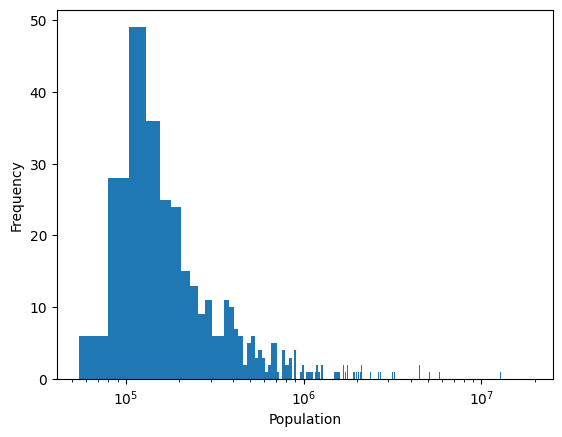

In [26]:
plt.hist(df["pop"].dropna(), bins=750) # plot shit on the log scale because the dynamic range increases
plt.xscale("log")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

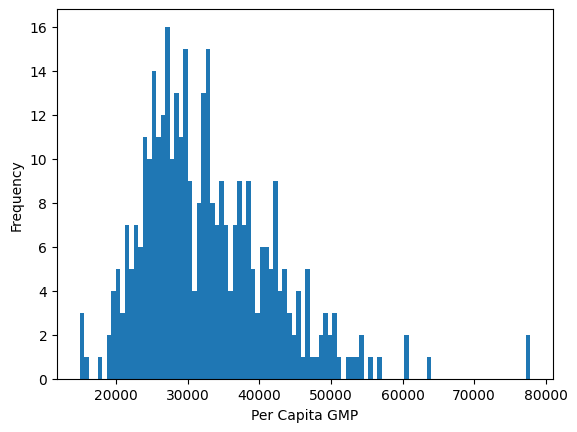

In [25]:
plt.hist(df["pcgmp"].dropna(), bins=100)
plt.xlabel("Per Capita GMP")
plt.ylabel("Frequency")
plt.show()

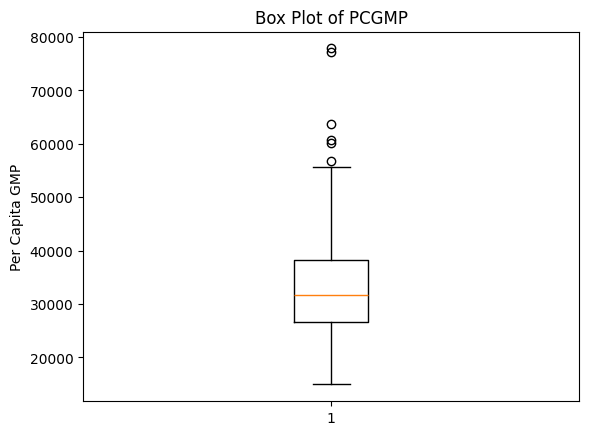

In [29]:
plt.boxplot(df["pcgmp"].dropna(), vert=True)
plt.ylabel("Per Capita GMP")
plt.title("Box Plot of PCGMP")
plt.show()

Text(0, 0.5, 'Population')

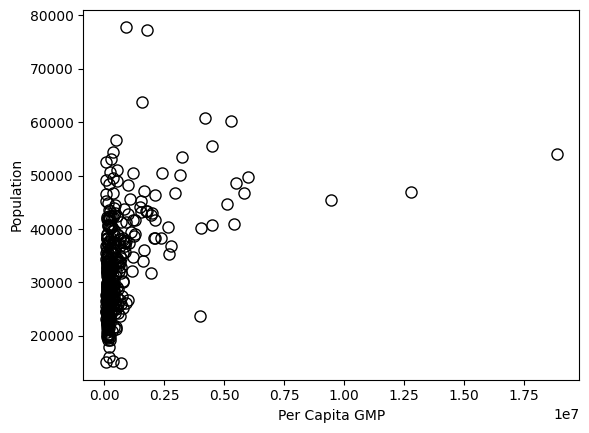

In [62]:
plt.plot(df["pop"], df["pcgmp"], 'o', markersize=8, fillstyle='none', color='black')
plt.xlabel("Per Capita GMP")
plt.ylabel("Population")

Text(0, 0.5, 'Population')

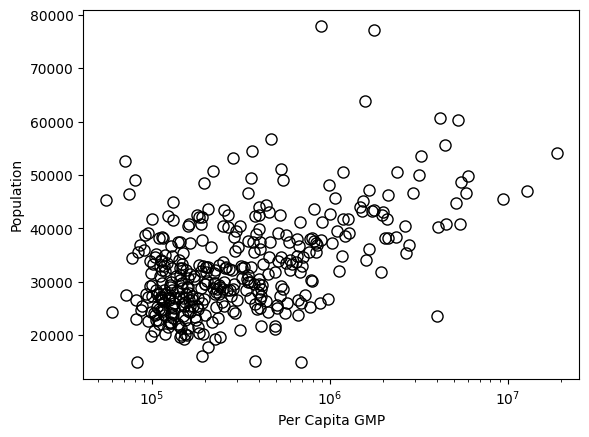

In [63]:
plt.plot(df["pop"], df["pcgmp"], 'o', markersize=8, fillstyle='none', color='black')
plt.xscale('log')
plt.xlabel("Population")
plt.ylabel("Per Capita GMP")

In [70]:
# Least Squares Regression of Pop vs PCGMP (X vs Y) parameter estimation

b1_hat = df["pop"].cov(df["pcgmp"])/df["pop"].var() # .var() computes an unbiased estimate of the variance
b0_hat = df["pcgmp"].mean() - b1_hat * df["pop"].mean()

print("slope: ", b1_hat)
print("intercept ", b0_hat)

slope:  0.0024162011487698356
intercept  31277.57368000741


In [133]:
import statsmodels.api as sm

df_XY = df[['pop', 'pcgmp']].dropna()

X = df_XY["pop"]
y = df_XY["pcgmp"]

X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()

print(model.summary())

0      158700.0
1      699300.0
2      163000.0
3      850300.0
4      816000.0
         ...   
361    230100.0
362    414000.0
363    576200.0
364    159800.0
365    185100.0
Name: pop, Length: 366, dtype: float64
                            OLS Regression Results                            
Dep. Variable:                  pcgmp   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     72.48
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           4.49e-16
Time:                        16:19:35   Log-Likelihood:                -3826.9
No. Observations:                 366   AIC:                             7658.
Df Residuals:                     364   BIC:                             7666.
Df Model:                           1                                         
Covariance Type:            nonrobust                                     

Text(0, 0.5, 'PCGMP')

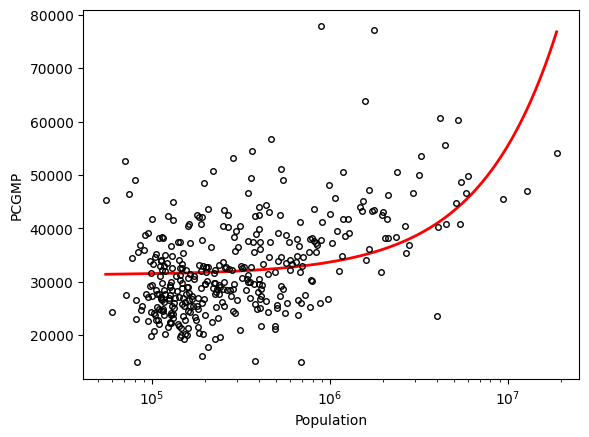

In [121]:
# Now gonna add the regression line to our scatter plot

X_vals = np.linspace(X.min(), X.max(), 200)
X_vals_sm = sm.add_constant(X_vals)
y_vals = model.predict(X_vals_sm)

# Regression line
plt.plot(X_vals, y_vals, color='red', linewidth=2, label="OLS fit")
plt.plot(X, y, 'o', markersize=4, fillstyle='none', color='black')
plt.xscale('log')


plt.xlabel("Population")
plt.ylabel("PCGMP")

In [146]:
index = df.index[df["MSA"] == "Pittsburgh, PA"][0]  # get index

# pittsburgh_row = df.loc[index]
# print(pittsburgh_row)

pred = model.fittedvalues.loc[index]
resid = model.resid.loc[index]
print("Predicted pcgmp for Pittsburgh:", pred)
print("Residual for Pittsburgh:", resid)
print("Resid squared:", resid**2)

Predicted pcgmp for Pittsburgh: 36982.224592253
Residual for Pittsburgh: 1367.7754077470017
Resid squared: 1870809.5660374768


In [148]:
residuals = model.resid
MSE = np.mean(residuals**2)
print(MSE)
print("ratio: ", resid**2/MSE)

# comparitively small

70697144.92297573
ratio:  0.026462307184762786


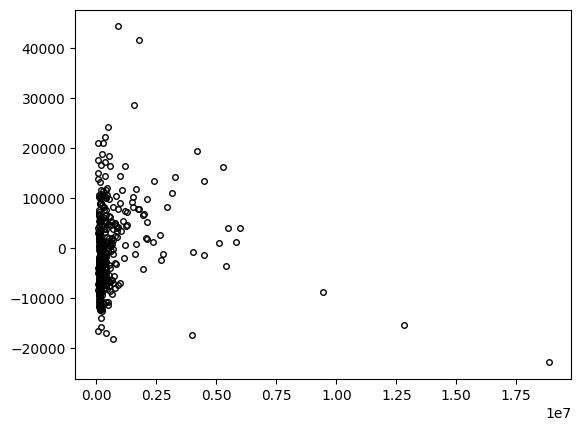

In [155]:
plt.plot(df["pop"], residuals, 'o', markersize=4, fillstyle='none', color='black')
# plt.xscale('log')
# should look like a constant width, blur of points around the line y = 0. Instead is a vertical bar around x=0, and then vanishes after that. Doesn't hold. 

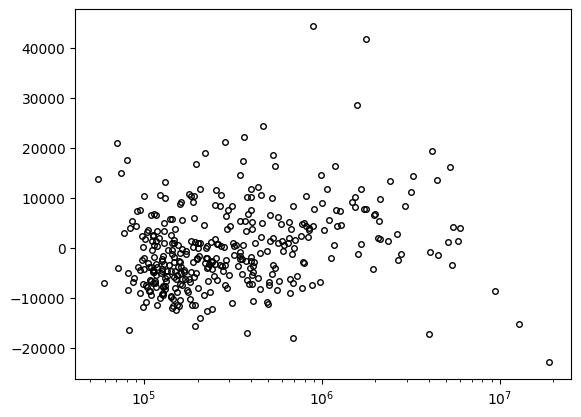

In [156]:
plt.plot(df["pop"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.xscale('log')

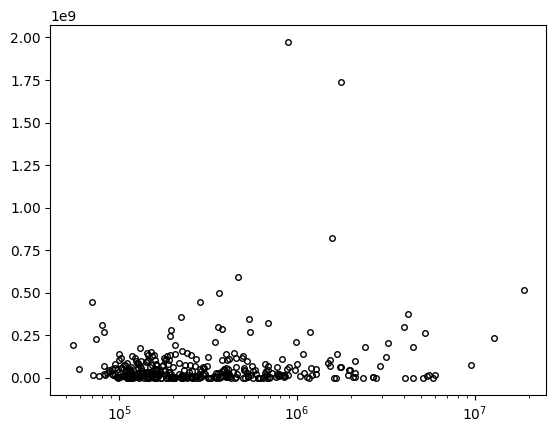

In [163]:
plt.plot(df["pop"], residuals**2, 'o', markersize=4, fillstyle='none', color='black')
# plt.yscale('log')
plt.xscale('log')

In [166]:
print(b1_hat * 1e+5)

# It would mean that per capita GMR would go up by 241 dollars assuming a causal relationship

241.62011487698356
